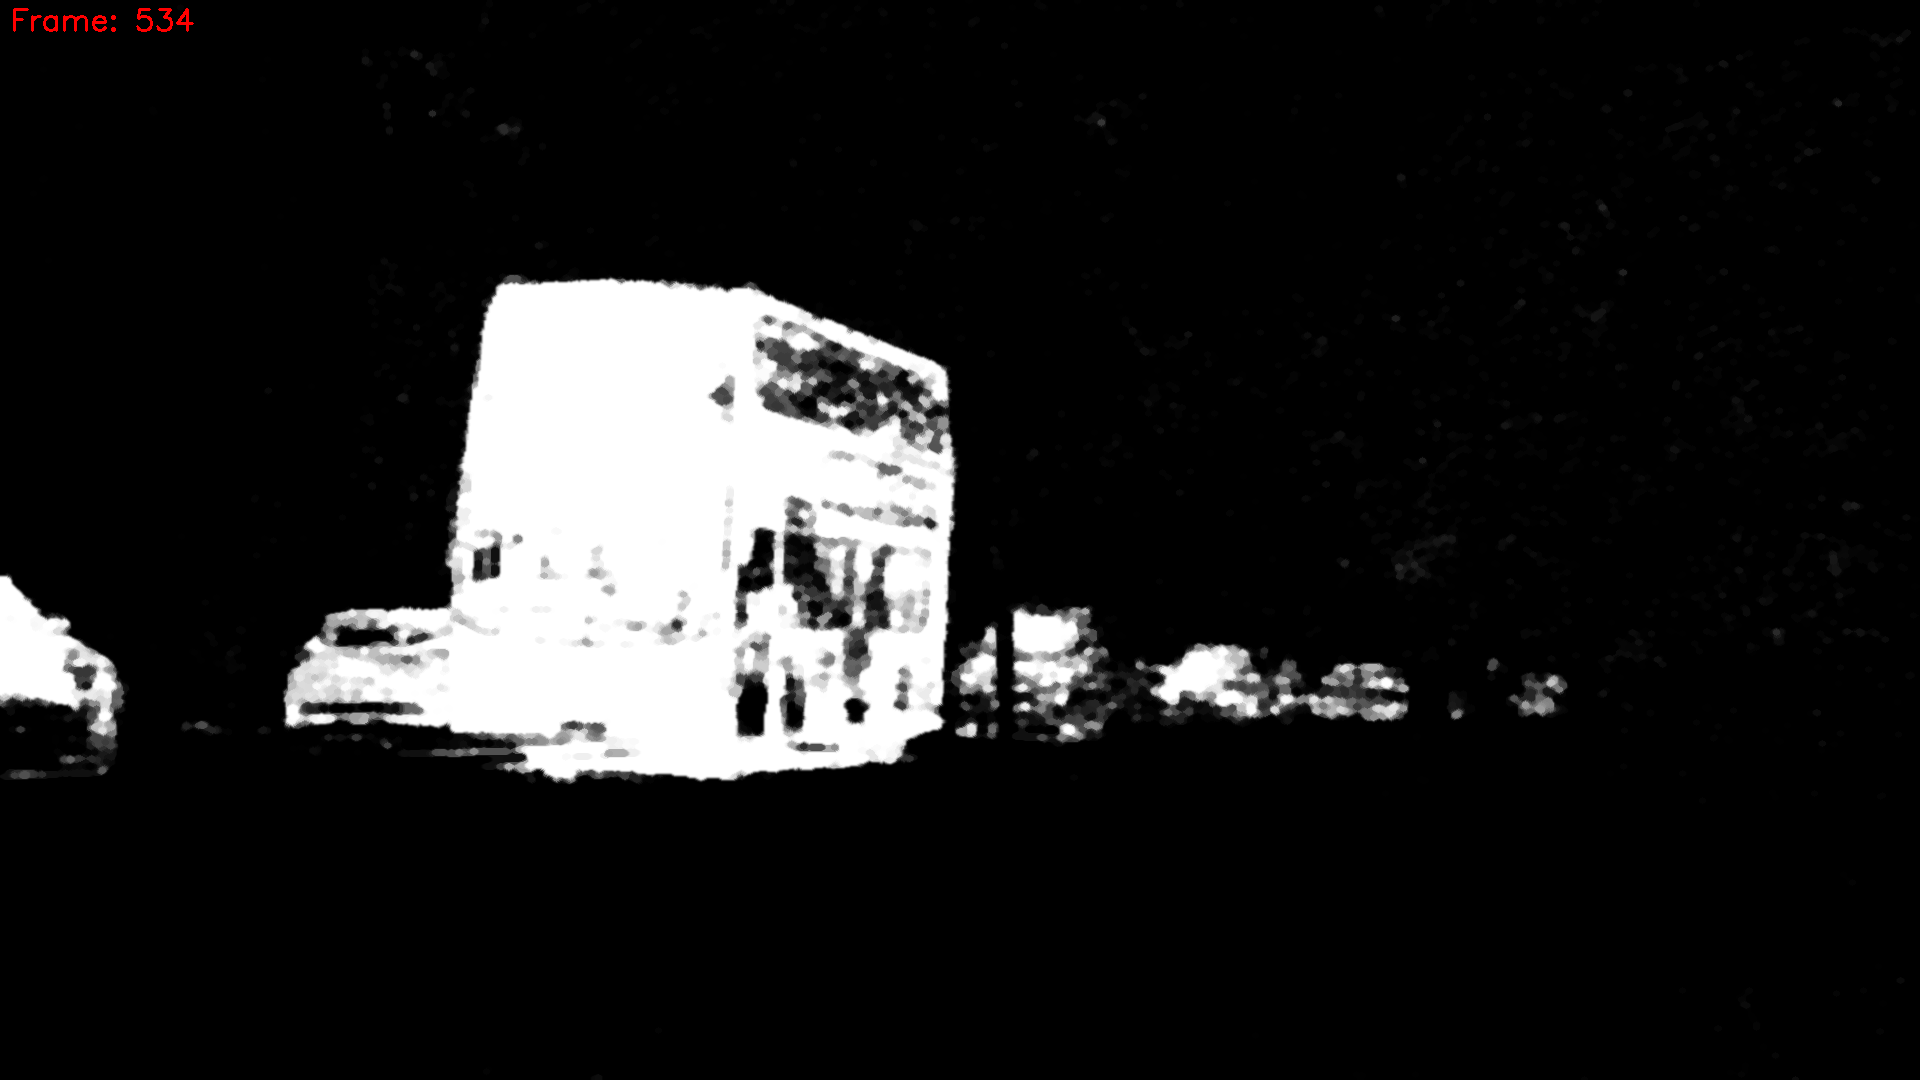

Processing complete


In [16]:
import cv2
from IPython.display import display, clear_output
from PIL import Image
import numpy as np

# 1. Verify video capture
cap = cv2.VideoCapture(r'video.mp4.mp4')
if not cap.isOpened():
    print("Error: Could not open video file")
else:
    print(f"Video loaded successfully - {cap.get(cv2.CAP_PROP_FRAME_COUNT)} frames available")

# 2. Initialize subtractor with better parameters
bg_subtractor = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=16,
    detectShadows=True
)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    # 3. Process frame
    fg_mask = bg_subtractor.apply(frame)
    
    # Debug: Show original frame and raw mask first
    # display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    # display(Image.fromarray(fg_mask))
    
    # 4. Modified processing pipeline
    _, fg_mask = cv2.threshold(fg_mask, 127, 255, cv2.THRESH_BINARY)  # Reduced threshold
    fg_mask = cv2.GaussianBlur(fg_mask, (5, 5), 0)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)
    
    # 5. Convert to 3-channel for better visualization
    fg_mask_rgb = cv2.cvtColor(fg_mask, cv2.COLOR_GRAY2RGB)
    
    # 6. Add frame number for verification
    cv2.putText(fg_mask_rgb, f"Frame: {int(cap.get(cv2.CAP_PROP_POS_FRAMES))}", 
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    
    clear_output(wait=True)
    display(Image.fromarray(fg_mask_rgb))
    
    # Add small delay if needed
    # time.sleep(0.03)

cap.release()
print("Processing complete")

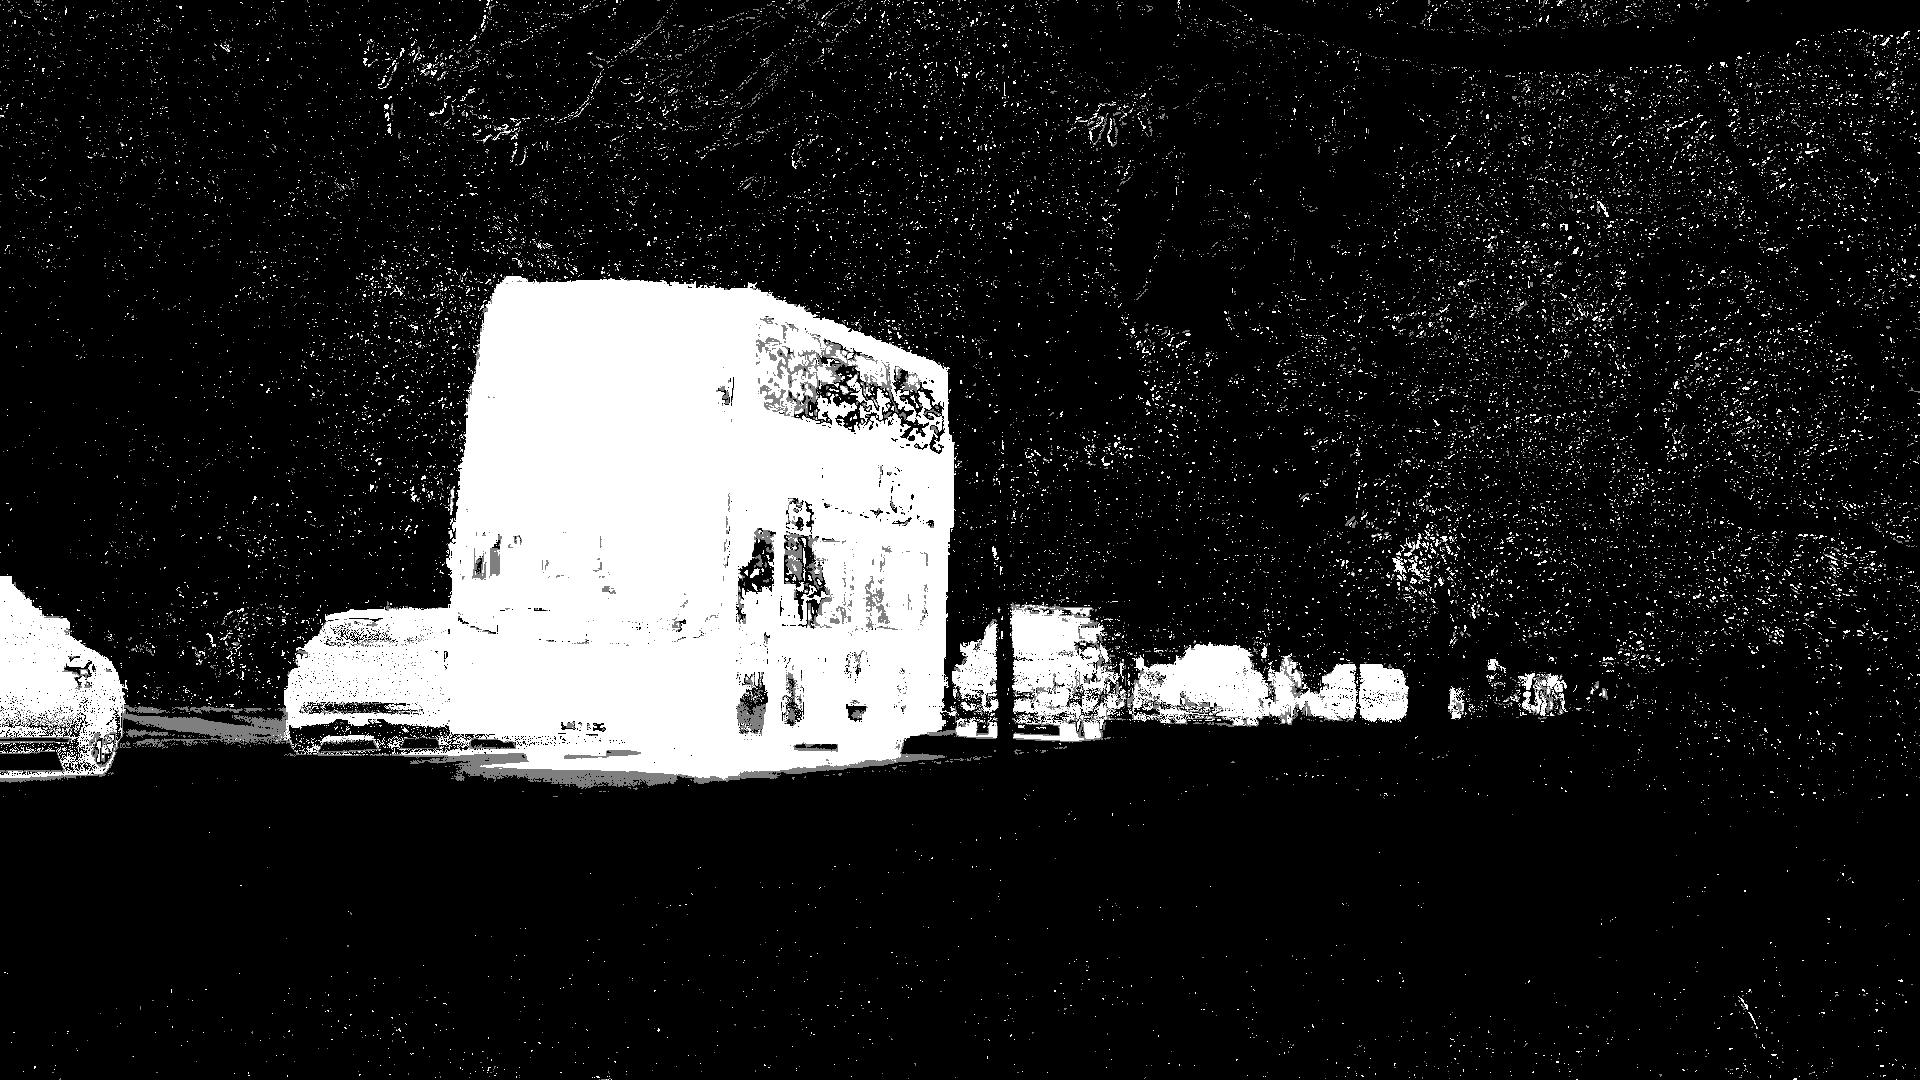

In [3]:
import cv2
from IPython.display import display, clear_output
from PIL import Image
cap = cv2.VideoCapture(r'video.mp4.mp4')
bg_subtractor = cv2.createBackgroundSubtractorKNN()
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    fg_mask = bg_subtractor.apply(frame)
    fg_img = Image.fromarray(fg_mask)
    clear_output(wait=True)
    display(fg_img)
cap.release()



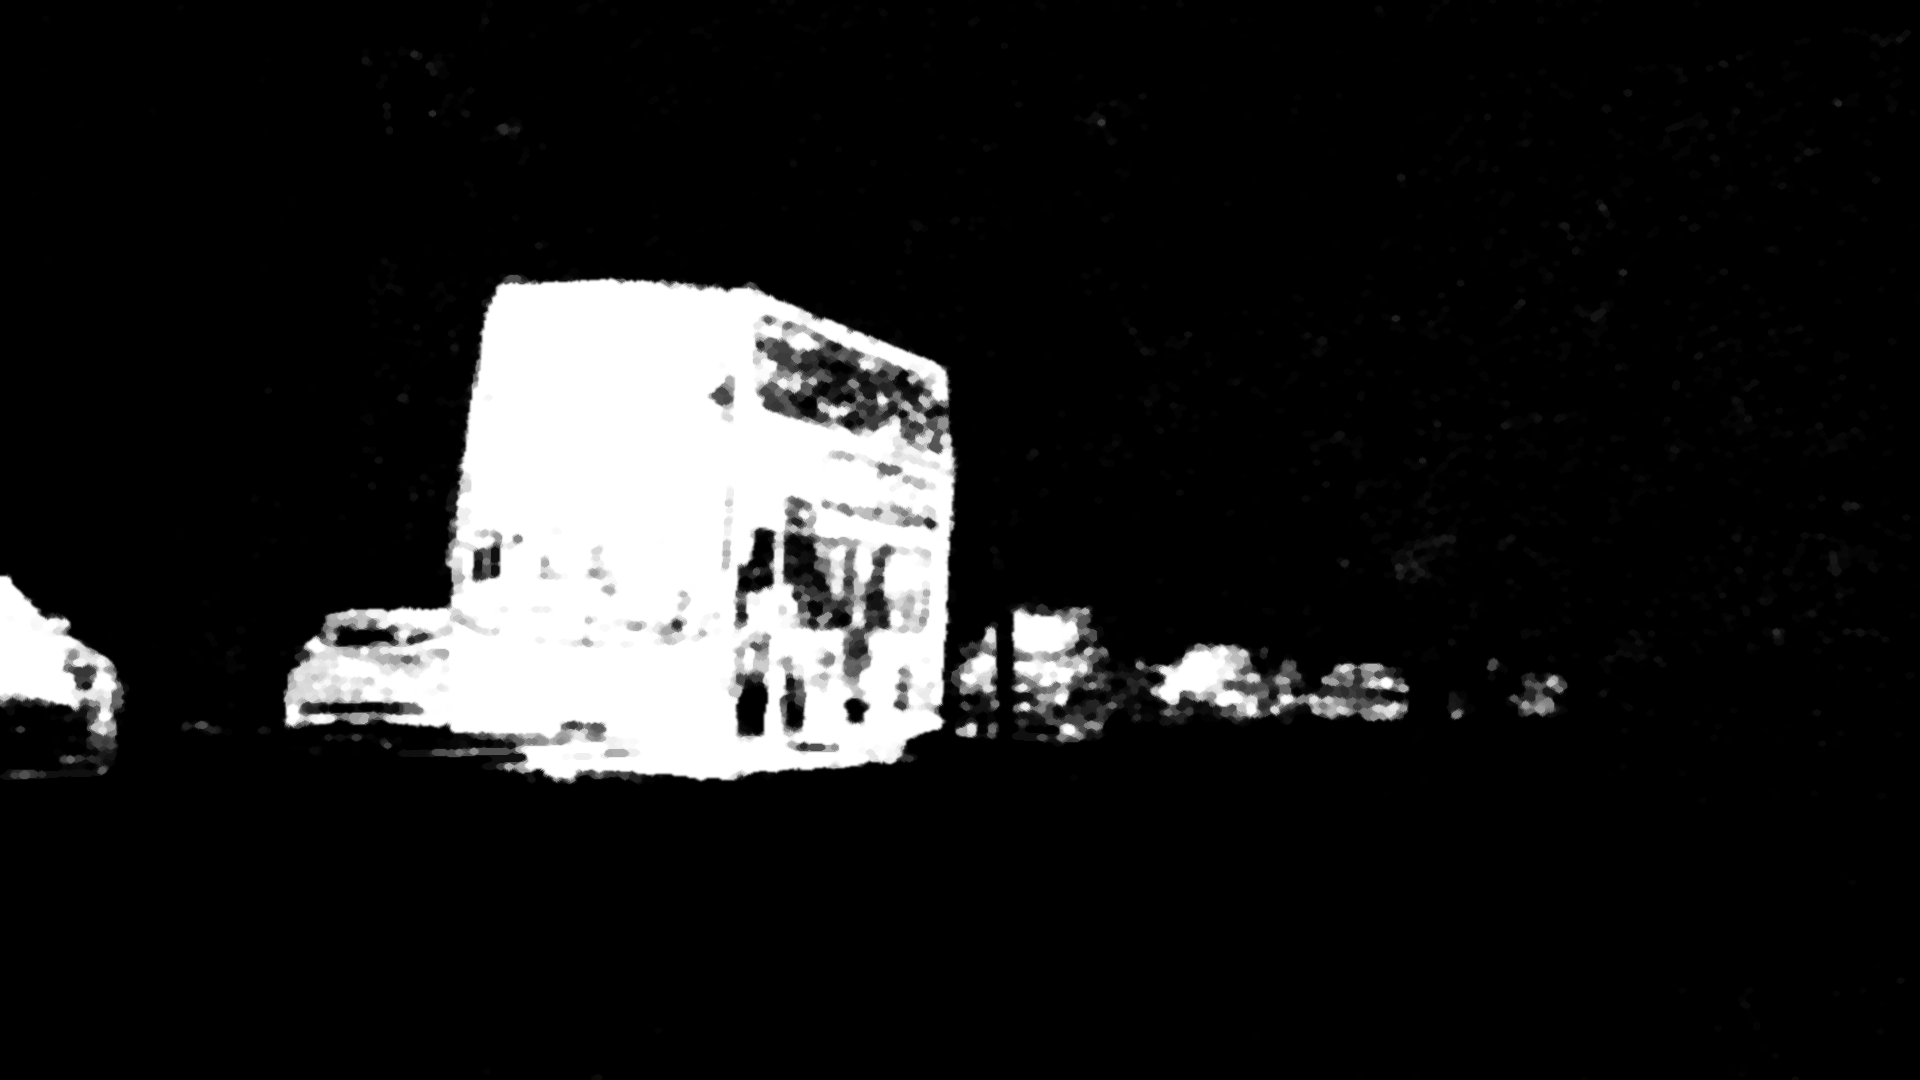

In [5]:
cap = cv2.VideoCapture(r'video.mp4.mp4')
bg_subtractor = cv2.createBackgroundSubtractorMOG2(detectShadows=True)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    fg_mask = bg_subtractor.apply(frame)
    _, fg_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)
    fg_mask = cv2.GaussianBlur(fg_mask, (5, 5), 0)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)
    fg_img = Image.fromarray(fg_mask)
    clear_output(wait=True)
    display(fg_img)
cap.release()

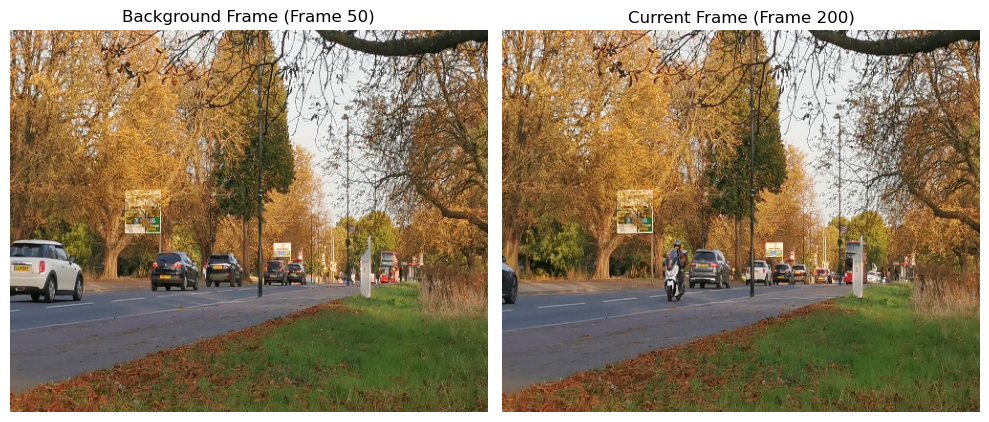

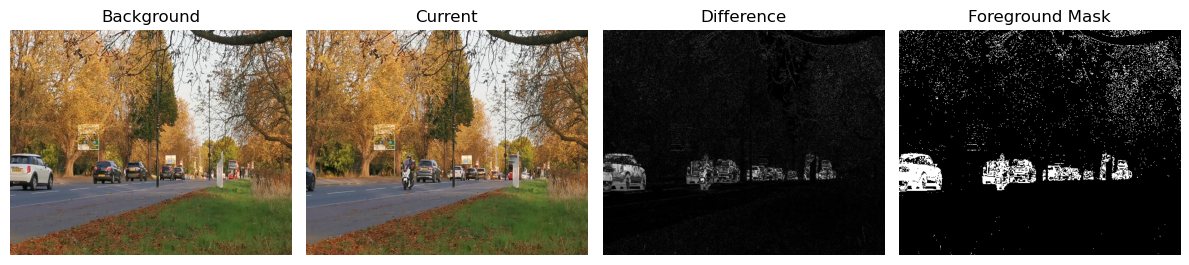

In [1]:
import cv2
import matplotlib.pyplot as plt

# STEP 1: Load video
cap = cv2.VideoCapture('video.mp4.mp4')

# STEP 2: Extract two specific frames
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret1, background = cap.read()

cap.set(cv2.CAP_PROP_POS_FRAMES, 200)
ret2, current = cap.read()

cap.release()

# STEP 3: Check if both frames are loaded
if not ret1 or not ret2:
    print("Error: Could not read one or both frames from the video.")
else:
    # Optional: Resize for uniformity
    background = cv2.resize(background, (500, 400))
    current = cv2.resize(current, (500, 400))

    # STEP 4: Display using matplotlib
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title("Background Frame (Frame 50)")
    plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Current Frame (Frame 200)")
    plt.imshow(cv2.cvtColor(current, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# STEP 2: Convert to grayscale
bg_gray = cv2.cvtColor(background, cv2.COLOR_BGR2GRAY)
cur_gray = cv2.cvtColor(current, cv2.COLOR_BGR2GRAY)

# STEP 3: Compute absolute difference and threshold
diff = cv2.absdiff(bg_gray, cur_gray)
_, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

# STEP 4: Display using matplotlib
plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.title("Background")
plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Current")
plt.imshow(cv2.cvtColor(current, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Difference")
plt.imshow(diff, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Foreground Mask")
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()